# Практическое занятие №9:Машинное обучение с scikit-learn III

Ансамбли (Случайный лес), подбор гиперпараметров (GridSearchCV), анализ
важности признаков

## Задание

1. Загрузить указанный датасет (все варианты используют датасеты, входящие в
библиотеку scikit-learn).
2. Выполнить разбиение на обучающую (80%) и тестовую (20%) выборки с
```random_state=42``` и ```stratify=y```.
3. Построить одиночное дерево решений (```DecisionTreeClassifier```) в качестве baseline.
4. Построить случайный лес (```RandomForestClassifier```) с параметрами по умолчанию.
5. Выполнить подбор гиперпараметров случайного леса с помощью ```GridSearchCV```
(минимальная сетка: ```n_estimators [50, 100, 200]```, ```max_depth [None, 10, 20]```,
```min_samples_split [2, 5]```).
6. Сравнить точность (accuracy) трёх моделей: дерево решений, случайный лес по
умолчанию, случайный лес после подбора.
7. Построить график важности признаков (горизонтальная столбчатая диаграмма).
8. Сделать вывод: какие признаки оказались наиболее важными для предсказания в
данной задаче?
9. Сформулировать итоговый вывод: стоит ли применять случайный лес вместо дерева в данной задаче и почему?

Вариант 10: Титаник (```titanic```, если доступен, или ```fetch_openml```)
- Датасет: при наличии доступа — встроенный датасет «Титаник»; иначе — синтетический датасет с категориальными признаками
-  Тип задачи: Бинарная классификация (выжил/не выжил)
- Особенность: выполнить кодирование категориальных признаков (```OneHotEncoder```) перед обучением; проанализировать, какие признаки оказались наиболее важными для прогнозирования выживания.

## Выполнение работы

### Импорт библиотек

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Загрузка датасета + Первичный анализ

В данной работе используется датасет Titanic.
Целевая переменная - выжил пассажир или нет.

In [33]:
# Загрузка датасета
titanic = sns.load_dataset('titanic')

# Размер датасета
print("\nShape of dataset:")
print(titanic.shape)

# Первые 5 строк датасета
print("\nПервые 5 строк:")
print(titanic.head())

# Информация о признаках
print("\nИнформация:")
print(titanic.info())

# Статистика числовых признаков
print("\nСтатистика числовых признаков:")
print(titanic.describe())

# Проверка пропущенных значений
print("\nПропущенные значения:")
print(titanic.isnull().sum())

# Распределение классов
print("\nРаспределение классов:")
print(titanic['survived'].value_counts())



Shape of dataset:
(891, 15)

Первые 5 строк:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------ 

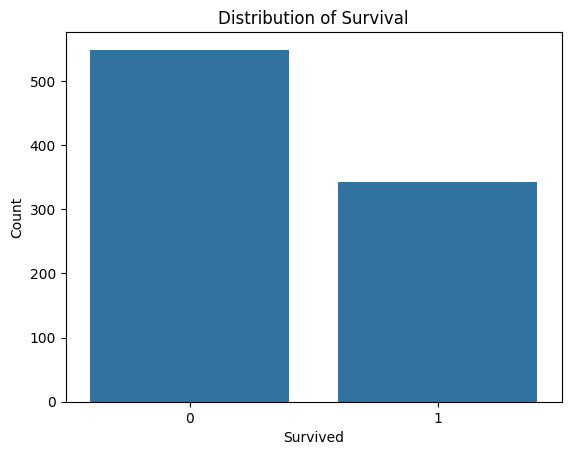

In [34]:
# Визуализация распределения target
sns.countplot(
    data=titanic,
    x='survived'
)

plt.title('Distribution of Survival')
plt.xlabel('Survived')
plt.ylabel('Count')

plt.show()

Датасет Titanic содержит числовые и категориальные признаки,
а также пропущенные значения.

Целевая переменная survived показывает, выжил пассажир или нет.

Также наблюдается дисбаланс классов: количество погибших пассажиров
больше количества выживших.

### Обработка пропущенных значений

In [35]:
# Проверка пропусков
print("Missing values before processing:")

print(
    titanic.isnull().sum()
)

Missing values before processing:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [36]:
# Удаление признака deck
titanic = titanic.drop(
    columns=['deck']
)

# Заполнение возраста медианой
titanic['age'] = titanic['age'].fillna(
    titanic['age'].median()
)

# Заполнение embarked модой
titanic['embarked'] = titanic['embarked'].fillna(
    titanic['embarked'].mode()[0]
)

# Заполнение embark_town модой
titanic['embark_town'] = titanic['embark_town'].fillna(
    titanic['embark_town'].mode()[0]
)

# Проверка после обработки
print("Пропущенные значений после обработки:")
print(titanic.isnull().sum())

Пропущенные значений после обработки:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


Пропущенные значения были обработаны.

Признак deck был удалён, так как содержал слишком большое количество пропусков.

Пропуски в признаке age были заполнены медианным значением, а категориальные признаки embarked и embark_town - наиболее часто встречающимся значением.

### Разделение данных на признаки и целевую переменную (таргет).

Перед обучением моделей необходимо выделить признаки (X) и целевую переменную (y).

Также требуется выполнить кодирование категориальных признаков
с помощью ```OneHotEncoder```.

In [37]:
# Удаление лишних признаков
titanic = titanic.drop(
    columns=['alive']
)

In [43]:
# Разделение на признаки и target
X = titanic.drop(
    columns=['survived']
)

y = titanic['survived']

# Проверка типов признаков
print(X.dtypes)

# Кодирование категориальных признаков
X = pd.get_dummies(
    X,
    drop_first=True
)

# Проверка после кодирования
print('\nПроверка типа данных:\n', X.head())


pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alone              bool
dtype: object

Проверка типа данных:
    pclass   age  sibsp  parch     fare  adult_male  alone  sex_male  \
0       3  22.0      1      0   7.2500        True  False      True   
1       1  38.0      1      0  71.2833       False  False     False   
2       3  26.0      0      0   7.9250       False   True     False   
3       1  35.0      1      0  53.1000       False  False     False   
4       3  35.0      0      0   8.0500        True   True      True   

   embarked_Q  embarked_S  class_Second  class_Third  who_man  who_woman  \
0       False        True         False         True     True      False   
1       False       False         False        False    False       True   
2       False      

Категориальные признаки были преобразованы в числовой формат (0/1 или T/F) с помощью ```OneHotEncoder```.

Это необходимо, так как модели машинного обучения не могут работать с текстовыми значениями напрямую.

### Разделение на обучающую и тестовую выборку.

In [46]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Проверка размеров выборок
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (712, 16)
Test shape: (179, 16)


Данные были разделены на обучающую и тестовую выборки в соотношении 80/20.

Параметр ```stratify=y``` позволил сохранить баланс классов в обеих выборках.

### Одиночное дерево решений (baseline)

In [56]:
# Создание модели дерева решений
tree = DecisionTreeClassifier(
    random_state=42
)

# Обучение модели
tree.fit(X_train, y_train)

# Предсказание
y_pred_tree = tree.predict(X_test)

# Accuracy (точность)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Decision Tree Точность:\n {tree_accuracy:.3f}")

# Classification report
print('\nClassification report:\n', classification_report(y_test, y_pred_tree)
)

Decision Tree Точность:
 0.810

Classification report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85       110
           1       0.76      0.74      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Одиночное дерево решений показало достаточно хорошее качество классификации.

Accuracy = 0.810 означает, что модель правильно предсказала
около 81% объектов тестовой выборки.

Для класса 0 (пассажиры, не выжившие) модель показывает более высокие значения precision и recall, чем для класса 1.

Для класса 1 (выжившие пассажиры) качество ниже, что связано с дисбалансом классов в датасете ```Titanic```.

В целом дерево решений успешно выявляет закономерности, связанные с выживанием пассажиров.

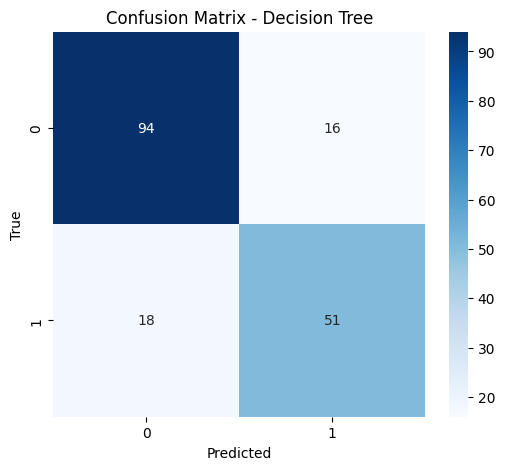

In [64]:
# Матрица ошибок
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix - Decision Tree')

plt.show()

Матрица ошибок показывает, что модель правильно классифицировала:
- 94 пассажира класса 0;
- 51 пассажира класса 1.

При этом были допущены ошибки:
- 16 ложноположительных предсказаний (FP);
- 18 ложноотрицательных предсказаний (FN).

Количество ошибок является умеренным, что соответствует accuracy около 81%.

Модель немного хуже определяет выживших пассажиров,
чем погибших.

### Случайный лес (Random Forest) с параметрами по умолчанию

In [62]:
# Создание модели случайного леса
rf_default = RandomForestClassifier(random_state=42)

# Обучение модели
rf_default.fit(
    X_train,
    y_train
)

# Предсказание
y_pred_rf_default = rf_default.predict(
    X_test
)

# Accuracy
rf_default_accuracy = accuracy_score(
    y_test,
    y_pred_rf_default
)

print(f"Random Forest Точность: {rf_default_accuracy:.3f}")

# Classification report
print('\nClassification report:\n', classification_report(y_test,y_pred_rf_default))

Random Forest Точность: 0.838

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



Случайный лес показал более высокое качество, чем одиночное дерево решений.

Accuracy увеличилась до 0.838, что означает, что модель правильно классифицировала около 84% объектов тестовой выборки.

Для класса 0 (пассажиры, не выжившие) модель показывает высокие значения precision и recall.

Для класса 1 (выжившие пассажиры) качество также улучшилось по сравнению с одиночным деревом решений.

Использование ансамбля деревьев позволило повысить устойчивость модели и улучшить качество классификации.

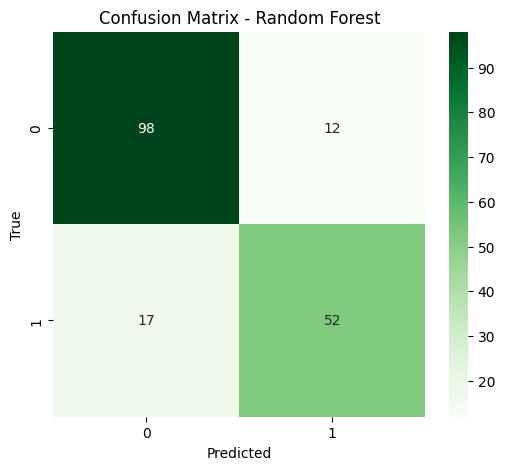

In [63]:
# Матрица ошибок
cm_rf_default = confusion_matrix(
    y_test,
    y_pred_rf_default
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_default,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix - Random Forest')

plt.show()

Матрица ошибок показывает, что модель правильно классифицировала:
- 98 пассажиров класса 0;
- 52 пассажира класса 1.

Количество ошибок уменьшилось по сравнению с одиночным деревом решений.

Модель допустила:
- 12 ложноположительных ошибок (FP);
- 17 ложноотрицательных ошибок (FN).

Это подтверждает, что случайный лес лучше обобщает данные и обеспечивает более точные предсказания.

### Подбор гиперпараметров с помощью GridSearchCV

In [77]:
# Сетка гиперпараметров
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Создание модели Random Forest
rf = RandomForestClassifier(
    random_state=42
)

# Создание GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Обучение GridSearchCV
grid_search.fit(
    X_train,
    y_train
)

# Лучшие параметры
print(" \nЛучшие параметры:\n")
print(grid_search.best_params_)

# Лучшая accuracy на кросс-валидации
print("\nЛучший CV score:\n")
print(grid_search.best_score_)

# Лучшая модель
best_rf = grid_search.best_estimator_

# Предсказание лучшей модели
y_pred_best = best_rf.predict(X_test)


# Accuracy лучшей модели
best_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(f"\nЛучшая Random Forest Точность: {best_accuracy:.3f}")

# Classification report
print("\nClassification report:\n")
print(classification_report(y_test,y_pred_best))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
 
Лучшие параметры:

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Лучший CV score:

0.823116320299419

Лучшая Random Forest Точность: 0.816

Classification report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



После подбора гиперпараметров случайный лес показал accuracy = 0.816.

Лучшие параметры модели:
- ```max_depth = 10```;
- ```min_samples_split = 5```;
- ```n_estimators = 100```.

Несмотря на подбор параметров, качество модели оказалось немного ниже, чем у Random Forest с параметрами по умолчанию.

Это показывает, что подбор гиперпараметров не всегда гарантирует улучшение качества на тестовой выборке.

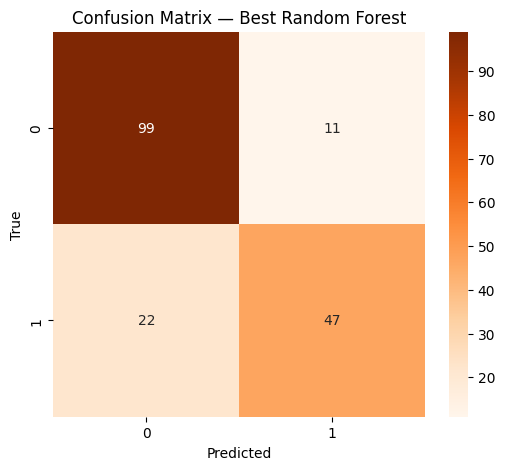

In [78]:
# Матрица ошибок
cm_best = confusion_matrix(y_test,y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix — Best Random Forest')
plt.show()

Матрица ошибок показывает, что модель правильно классифицировала:
- 99 пассажиров класса 0;
- 47 пассажиров класса 1.

При этом были допущены:
- 11 ложноположительных ошибок (FP);
- 22 ложноотрицательные ошибки (FN).

Модель лучше определяет пассажиров, которые не выжили, чем выживших пассажиров.

Количество ошибок остаётся сравнительно небольшим, что подтверждает хорошее качество модели.

### Сравнение моделей

In [80]:
# Таблица сравнения моделей
comparison = pd.DataFrame({

    'Model': [
        'Decision Tree',
        'Random Forest',
        'Best Random Forest'
    ],

    'Accuracy': [
        tree_accuracy,
        rf_default_accuracy,
        best_accuracy
    ]
})

print(comparison)

                Model  Accuracy
0       Decision Tree  0.810056
1       Random Forest  0.837989
2  Best Random Forest  0.815642


Наилучшее качество показал Random Forest с параметрами по умолчанию.

Случайный лес превзошёл одиночное дерево решений, так как использует ансамбль деревьев и лучше обобщает данные.

Подбор гиперпараметров не привёл к улучшению accuracy на тестовой выборке, однако позволил найти более оптимальную конфигурацию модели.

### Важность признаков

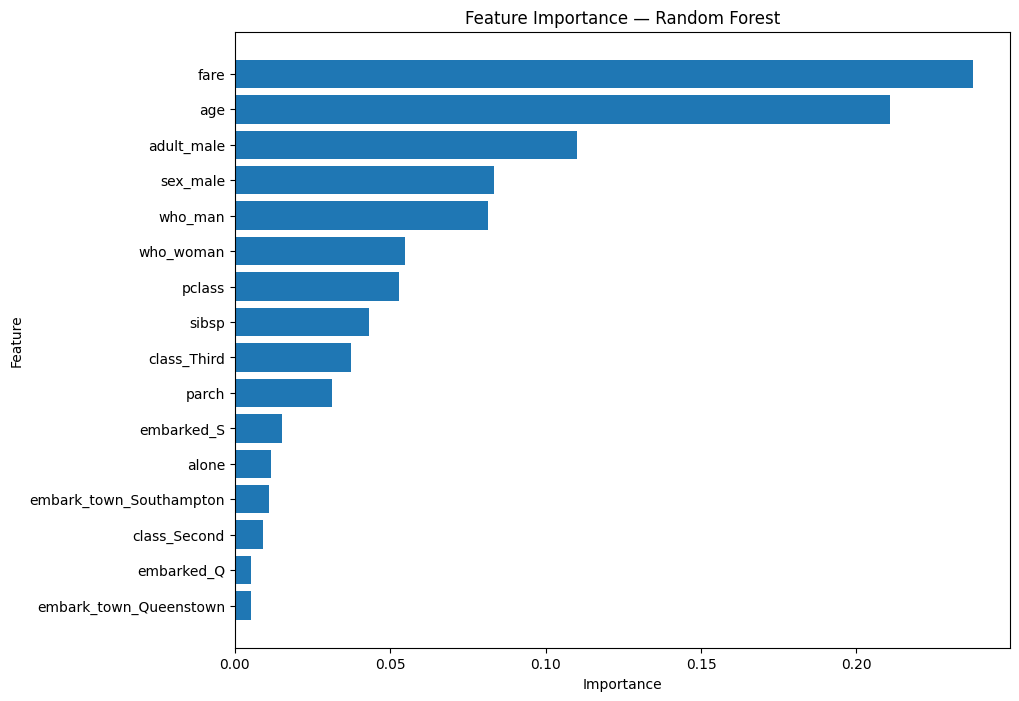

In [ ]:
# Получение важности признаков
feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_default.feature_importances_
})

# Сортировка признаков
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

# График важности признаков
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')
plt.show()

График важности признаков показывает, что наибольшее влияние на вероятность выживания пассажира оказали признаки:
- fare;
- age;
- adult_male;
- sex_male.

Это означает, что пол, возраст и социальный статус пассажира
существенно влияли на вероятность выживания на Titanic.

Наименее важными признаками оказались признаки, связанные с портом посадки и некоторыми категориями класса билета.

Полученные результаты соответствуют историческим данным,
согласно которым женщины, дети и пассажиры более высокого класса имели больше шансов на спасение.

### Итоговый вывод

В данной задаче использование Random Forest является более предпочтительным, чем применение одного дерева решений.

Случайный лес показал более высокую accuracy и более стабильные результаты классификации.

Это связано с тем, что Random Forest использует ансамбль деревьев, что снижает вероятность переобучения и повышает способность модели
обобщать данные.

Одиночное дерево решений работает быстрее и проще, однако сильнее зависит от структуры обучающих данных и может переобучаться.

Таким образом, для задачи прогнозирования выживания пассажиров ```Titanic``` Random Forest является более эффективной
и надёжной моделью.